In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [24]:
def harmonic_mean_filter(image, mask_size):
    filteredImg = image.copy()
    height, width = filteredImg.shape
    offset, number_of_pixels = mask_size//2, mask_size*mask_size

    for i in range(height):
        for j in range(width):
            pixel = 0
            for x in range(-offset, offset+1):
                for y in range(-offset, offset+1):
                    if (i+x>=0 and i+x<height and j+y>=0 and j+y<width):
                        pixel += float(1 / (image[i + x, j + y] + 1e-4))
            pixel = number_of_pixels / pixel
            filteredImg[i][j] = min(pixel, 255)

    return filteredImg

In [49]:
def geometric_mean_filter(image, mask_size):
    filteredImg = image.copy()
    height, width = filteredImg.shape
    offset, number_of_pixels = mask_size//2, mask_size*mask_size

    for i in range(height):
        for j in range(width):
            pixel = 1
            count = 0
            for x in range(-offset, offset+1):
                for y in range(-offset, offset+1):
                    if (i+x>=0 and i+x<height and j+y>=0 and j+y<width):
                        #if image[i+x][j+y] > 0:
                        pixel = pixel * int(image[i+x][j+y])
                        count = count + 1
            count = max(1, count)
            filteredImg[i][j] = pixel ** (1/count)

    return filteredImg

In [20]:
def add_salt_pepper_noise(image, noise_percent):
    height, width = image.shape
    noisedImg = image.copy()

    noise_amount = int((height*width)*(noise_percent/100))
    
    for i in range(noise_amount):
        salt_x, salt_y = np.random.randint(0,height), np.random.randint(0,width)
        pepper_x, pepper_y = np.random.randint(0,height), np.random.randint(0,width)

        noisedImg[salt_x][salt_y] = 255
        noisedImg[pepper_x][pepper_y] = 0
    return noisedImg
                    

In [51]:
def calculate_psnr(image1, image2):
    image1, image2 = np.float64(image1), np.float64(image2)
    mse = np.mean((image1 - image2)**2)
    if mse == 0:
        return 'inf'
    psnr = 20*np.log10(255.0) - 10*np.log10(mse)
    return round(psnr, 2)

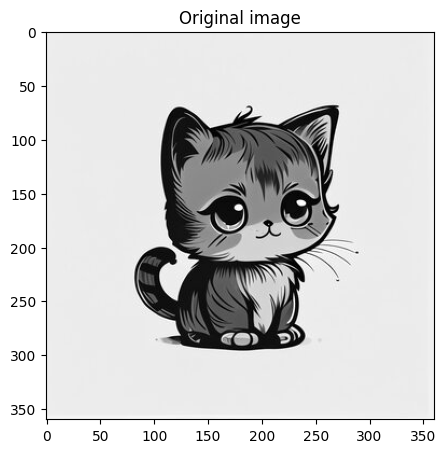

In [28]:
originalImg = cv2.imread('Cat 360x360.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,10))
plt.title('Original image')
plt.imshow(originalImg, cmap='gray')
plt.show()


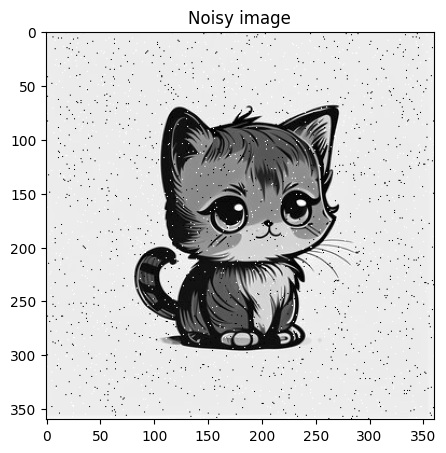

In [34]:
plt.figure(figsize=(5,10))
plt.title('Noisy image')
noise_percent = 1
noisy_image = add_salt_pepper_noise(originalImg, noise_percent)
plt.imshow(noisy_image, cmap='gray')
plt.show()


### Applying Harmonic mean filter

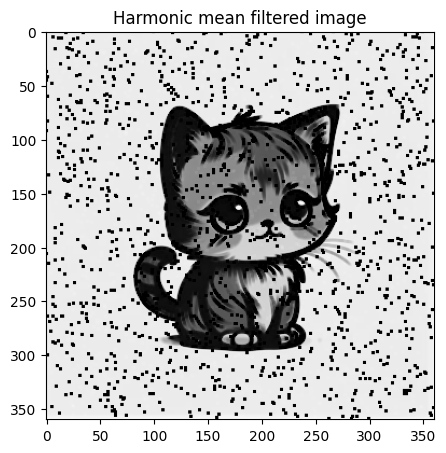

11.9


In [54]:
filter_size = 3
harmonic_mean_filtered_image = harmonic_mean_filter(noisy_image, filter_size)

plt.figure(figsize=(5,10))
plt.title('Harmonic mean filtered image')
plt.imshow(harmonic_mean_filtered_image, cmap='gray')
plt.show()
print(calculate_psnr(harmonic_mean_filtered_image, noisy_image))

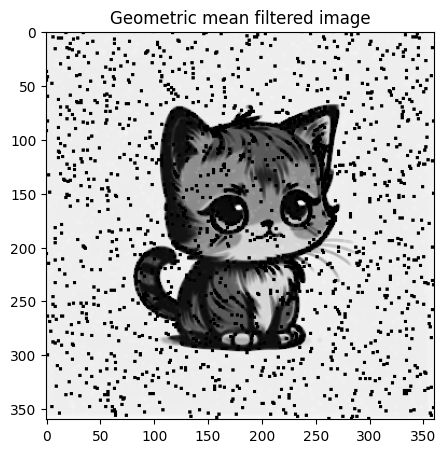

12.11


In [53]:
filter_size = 3
geometric_mean_filtered_image = geometric_mean_filter(noisy_image, filter_size)

plt.figure(figsize=(5,10))
plt.title('Geometric mean filtered image')
plt.imshow(geometric_mean_filtered_image, cmap='gray')
plt.show()
print(calculate_psnr(noisy_image, geometric_mean_filtered_image))